# 로지스틱 회귀(Logistic Regression)

분류에 사용되는 ML 모델

## 시그모이드 함수
학습을 통해서 구해지는 예측값을 0 ~ 1 사이의 학률값으로 변경 해주는 함수



In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'Malgun gothic'
plt.rcParams['axes.unicode_minus'] = False

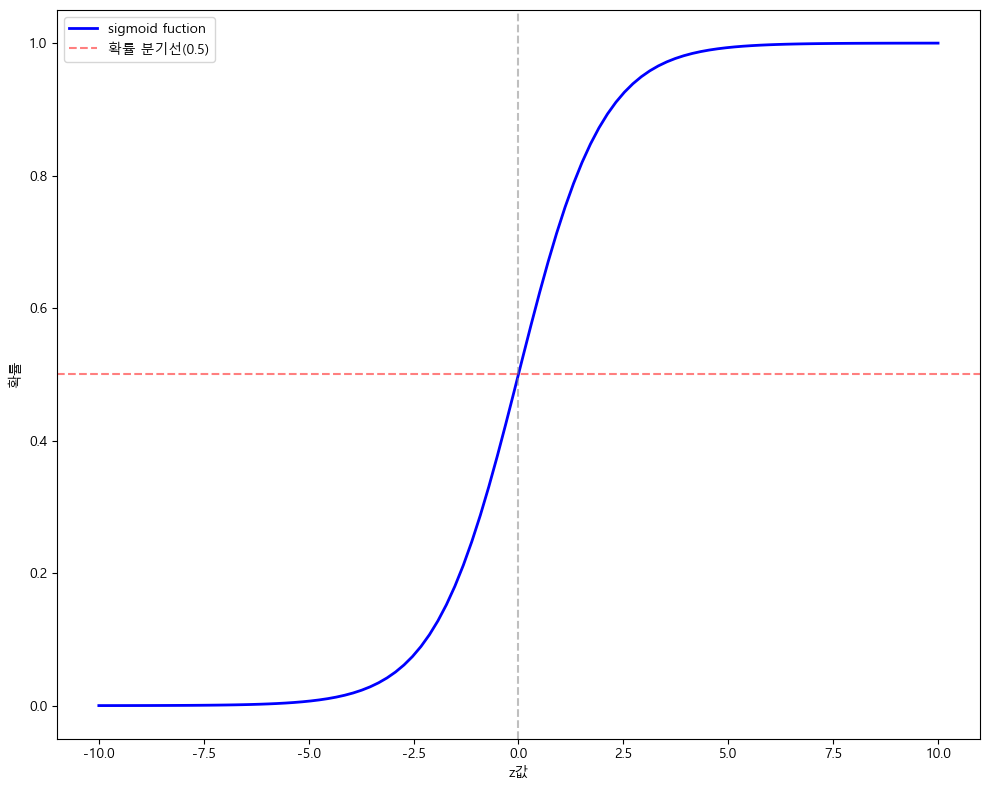

In [55]:
import numpy as np

def sigmoid(z) : 
    return 1/ (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
result = sigmoid(z)

plt.figure(figsize=(10,8))
plt.plot(z,result,color='blue',linewidth=2, label='sigmoid fuction')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5) # 수직선
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label= '확률 분기선(0.5)') # 수평선

plt.xlabel('z값')
plt.ylabel('확률')
plt.tight_layout()
plt.legend()
plt.show()



In [56]:
df = pd.read_csv('data/titanic.csv')
df.head(3)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1


In [57]:
cols = [ col for col in df.columns if col.startswith('zero')]
df = df.drop(columns=['Passengerid'] +cols)
df.head(3)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1


In [58]:
#컬럼명 수정하기
df = df.rename(columns={'2urvived':'Survived'})
df.head(3)

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1


In [59]:
# Embarked 데이터 종류 확인하기
df['Embarked'].nunique()

3

In [60]:
# 데이터 종류별 개수 확인하기
df['Embarked'].value_counts()

Embarked
2.0    914
0.0    270
1.0    123
Name: count, dtype: int64

In [61]:
#결측지 확인하기
df.isnull().sum().sum()

2

In [62]:
df.isnull().sum()

Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
Survived    0
dtype: int64

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1309 non-null   float64
 1   Fare      1309 non-null   float64
 2   Sex       1309 non-null   int64  
 3   sibsp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Pclass    1309 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [64]:
# 결측치 삭제하기
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1307 non-null   float64
 1   Fare      1307 non-null   float64
 2   Sex       1307 non-null   int64  
 3   sibsp     1307 non-null   int64  
 4   Parch     1307 non-null   int64  
 5   Pclass    1307 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1307 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 91.9 KB


In [65]:
x = df.drop(columns='Survived')
y = df['Survived']

print(x.shape)
print(y.shape)

(1307, 7)
(1307,)


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)

(1045, 7)
(1045,)


## 스케일링 적용여부 결정하기

|모델|스케일링|이유|
|---|---|---|
|선형회귀|선택적|예측값은 안변함, 계수(coef)값은 비교하려면 권장|
|로지스틱회귀|권장|sklearn에 의해 권장되고 있음|
|Decision Tree|불필요|...|
|랜덤포레스트|불필요|...|
|Gradient Boost|불필요|...|
|Deep Learning|필수|여러 변수들을 표준화하여 지속적인 연산을 수행함|

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # 평균 0, 표준편차가 1인 값들로 스케일링
X_train_s = scaler.fit_transform(X_train) # 학습과 변환
X_test_s = scaler.transform(X_test)

#로지스틱 회귀 모델 생성과 학습
logiReg = LogisticRegression(random_state=42)
model = logiReg.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

s_coef = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
s_coef



Sex         0.875054
Pclass     -0.632251
Age        -0.363765
sibsp      -0.140624
Parch      -0.037494
Embarked   -0.028073
Fare        0.001856
dtype: float64

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_score = accuracy_score(y_test,y_pred)
print(acc_score)

0.7900763358778626


In [ ]:
print(classification_report(y_test,y_pred))

# 0(사망), 1(생존)
# precision : 생존(사망)이라고 예측한 사람중 진짜 생존(사망)은 몇 퍼센트인가?
# recall : 실제 생존(사망)자 중 몇 명을 찾아 냈는가?
# f1-score : pr + re를 조합하여 최종 점수를 책정함


              precision    recall  f1-score   support

           0       0.80      0.95      0.87       192
           1       0.73      0.34      0.47        70

    accuracy                           0.79       262
   macro avg       0.76      0.65      0.67       262
weighted avg       0.78      0.79      0.76       262



In [71]:
print(confusion_matrix(y_test, y_pred))

[[183   9]
 [ 46  24]]
